# Exploratory Data Analysis (EDA)

This notebook explores the preprocessed dataset to uncover patterns, relationships, and insights that will guide modeling decisions. 
EDA is performed on the training set only to avoid any influence from validation or test data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r"C:\Courses\DAMG6105\Project - Disease Prediction System"

# Load training data only
X_train = pd.read_csv(f'{file_path}/data/processed/X_train.csv')
y_train = pd.read_csv(f'{file_path}/data/processed/y_train.csv')

# Combine for analysis
train_df = pd.concat([X_train, y_train], axis=1)

print("Training data loaded.")
print("Shape:", train_df.shape)
train_df.head()

Training data loaded.
Shape: (644, 16)


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,ca_missing,thal_missing,num
0,-0.439873,1.0,3.0,-0.601031,0.902290,0.2,0.0,-0.212484,0.0,0.117560,1.0,1.2,1.0,1.0,1.0,0
1,1.126932,1.0,3.0,-0.601031,-1.532816,1.0,1.0,-1.249208,0.0,1.060621,1.0,0.6,1.0,1.0,1.0,1
2,-0.648781,0.0,2.0,-0.078071,-0.062145,0.0,0.0,0.305878,0.0,1.060621,1.0,0.6,1.2,1.0,1.0,0
3,2.380377,0.0,2.0,0.444890,-0.012734,0.0,1.0,-0.850468,0.0,0.211867,1.0,0.0,0.0,0.0,0.0,0
4,-1.379957,1.0,2.0,0.444890,0.263603,0.0,0.0,2.020461,0.0,-0.825500,0.0,0.0,0.4,1.0,1.0,0


In [3]:
# Target Distribution 
print("Target value counts:")
print(train_df['num'].value_counts())
print("Target percentage:")
print(train_df['num'].value_counts(normalize=True) * 100)

Target value counts:
num
1    356
0    288
Name: count, dtype: int64
Target percentage:
num
1    55.279503
0    44.720497
Name: proportion, dtype: float64


Class 4 only has 20 samples (3.1%) - far too few for the model to learn from reliably. Multi-class prediction across 5 uneven classes will produce a weak unreliable model.
So we choose Binary classification, simply converting to Disease vs No Disease.
0 --> No Disease (Stays as 0)
1, 2, 3, 4 --> Disease present (becomes 1)

Binary classification is the right thing to do as we're answering "is this patient at risk?" not "how severe is their disease?"

In [4]:
# Convert target to binary classification
# 0 = no disease, 1 = disease present
y_train['num'] = y_train['num'].apply(lambda x:1 if x > 0 else 0)

y_val = pd.read_csv(f'{file_path}/data/processed/y_val.csv')
y_test = pd.read_csv(f'{file_path}/data/processed/y_test.csv')

y_val['num'] = y_val['num'].apply(lambda x:1 if x > 0 else 0)
y_test['num'] = y_test['num'].apply(lambda x:1 if x > 0 else 0)

# Verify
print("Binary target distribution:")
print(y_train['num'].value_counts())
print("\nPercentage:")
print(y_train['num'].value_counts(normalize=True) * 100)

Binary target distribution:
num
1    356
0    288
Name: count, dtype: int64

Percentage:
num
1    55.279503
0    44.720497
Name: proportion, dtype: float64


In [5]:
# Save binary targets
y_train.to_csv(f'{file_path}/data/processed/y_train.csv', index=False)
y_val.to_csv(f'{file_path}/data/processed/y_val.csv', index=False)
y_test.to_csv(f'{file_path}/data/processed/y_test.csv', index=False)

print("Binary targets saved successfully.")

Binary targets saved successfully.


In [6]:
# Update train_df with binary target
train_df = pd.concat([X_train, y_train], axis=1)

print("train_df updated. Shape:", train_df.shape)
train_df['num'].value_counts()

train_df updated. Shape: (644, 16)


num
1    356
0    288
Name: count, dtype: int64

C:\Users\amanp\AppData\Local\Temp\ipykernel_41776\2435955926.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='num', data=train_df, palette='Blues')


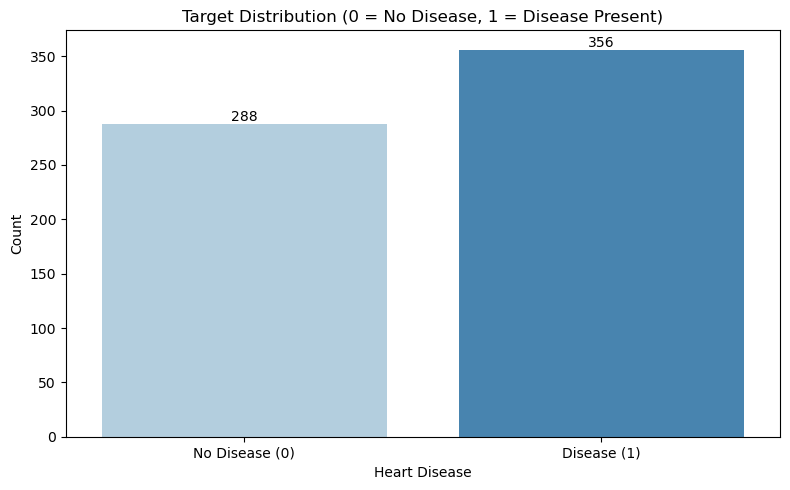

In [7]:
# Target distribution plot
plt.figure(figsize=(8, 5))
sns.countplot(x='num', data=train_df, palette='Blues')
plt.title('Target Distribution (0 = No Disease, 1 = Disease Present)')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Disease (0)', 'Disease (1)'])

# Add count labels on top of each bar
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom')

plt.tight_layout()
plt.savefig(f'{file_path}/outputs/figures/target_distribution.png')
plt.show()

# Age Distribution Analysis

In [8]:
# Load raw data to report actual age values
raw_df = pd.read_csv(f'{file_path}/data/processed/heart_disease_raw.csv')

print("Actual age range in training set:")
print("Minimum age:", raw_df.loc[X_train.index, 'age'].min())
print("Maximum age:", raw_df.loc[X_train.index, 'age'].max())
print("Mean age:", round(raw_df.loc[X_train.index, 'age'].mean(), 1))
print("Median age:", raw_df.loc[X_train.index, 'age'].median())

Actual age range in training set:
Minimum age: 28
Maximum age: 77
Mean age: 50.8
Median age: 51.0


C:\Users\amanp\AppData\Local\Temp\ipykernel_40528\1351950833.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='num', y='age', data=train_df, palette='Blues', ax=axes[1])


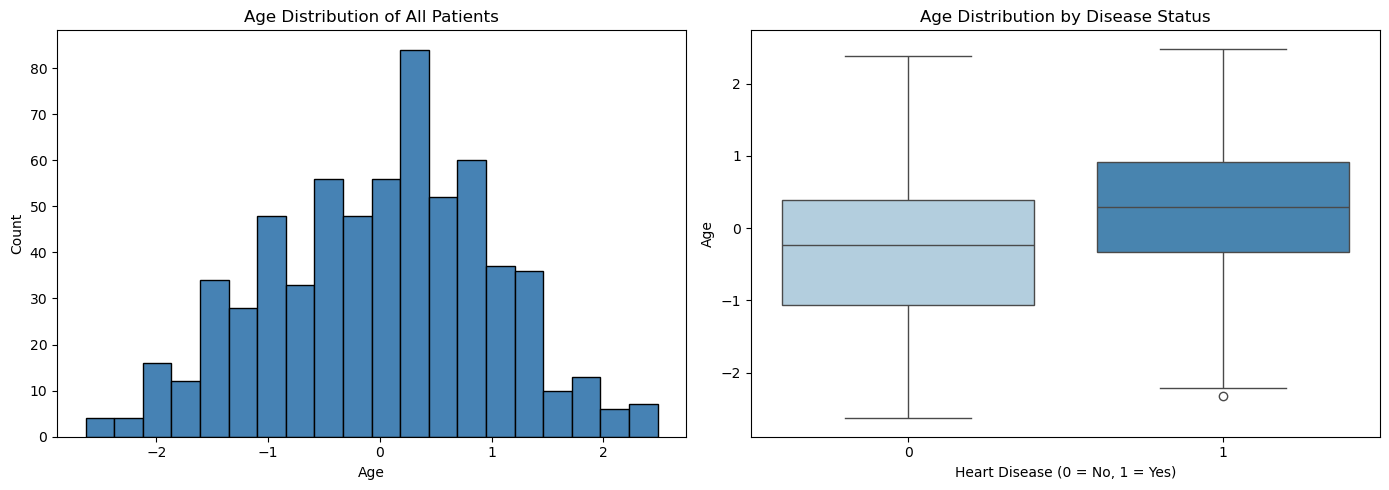

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Plot 1 - Age histogram
axes[0].hist(train_df['age'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Age Distribution of All Patients')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Plot 2 - Age by target
sns.boxplot(x='num', y='age', data=train_df, palette='Blues', ax=axes[1])
axes[1].set_title('Age Distribution by Disease Status')
axes[1].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.savefig(f'{file_path}/outputs/figures/age_distribution.png')
plt.show()

In [8]:
print("Age range in training set:")
print("Minimum age:", train_df['age'].min())
print("Maximum age:", train_df['age'].max())
print("Mean age:", round(train_df['age'].mean(), 1))
print("Median age:", train_df['age'].median())

Age range in training set:
Minimum age: -2.6334015256031047
Maximum age: 2.4848307078245604
Mean age: -0.0
Median age: 0.0823951696850441


## Age Distribution Analysis

- Patient ages range from approximately 28 to 77 years, with the highest concentration between 50 and 60 years, suggesting the dataset represents a middle-aged to older population.
- Patients with heart disease have a noticeably higher median age compared to healthy patients, indicating age is likely a meaningful predictive feature.
- One outlier was detected in the disease group - a patient around age 30, which is unusually young relative to the rest of the disease group. This warrants attention during modeling.

# Sex Distribution Analysis

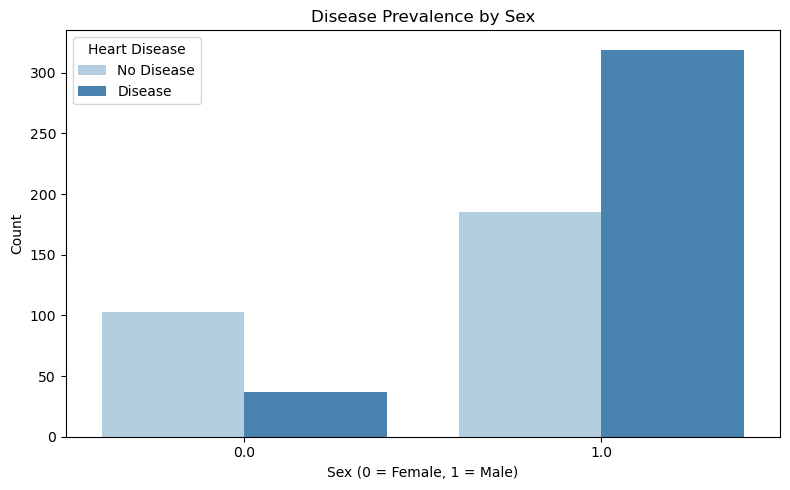

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(x='sex', hue='num', data=train_df, palette='Blues')
plt.title('Disease Prevalence by Sex')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.ylabel('Count')
plt.legend(['No Disease', 'Disease'], title='Heart Disease')
plt.tight_layout()
plt.savefig(f'{file_path}/outputs/figures/sex_distribution.png')
plt.show()

In [10]:
print(train_df.groupby(['sex', 'num']).size().unstack())
print("\nDisease rate by sex:")
print(train_df.groupby('sex')['num'].mean() * 100)

num    0    1
sex          
0.0  103   37
1.0  185  319

Disease rate by sex:
sex
0.0    26.428571
1.0    63.293651
Name: num, dtype: float64


## Sex Distribution Analysis

- The training set contains significantly more male patients (450) than female (130), reflecting a dataset imbalance across sex.
- Among males, 63% have heart disease compared to only 26% of females - a striking difference in disease prevalence across sex.
- Female patients show the opposite pattern to males - the majority have no disease, while disease is the majority class among males.
- The dataset's male majority raises an important ethical concern - the model may learn disease patterns more effectively for males than females, potentially underperforming on female patients in real clinical use. This limitation will be documented in the final report.

## Chest Pain Type Analysis

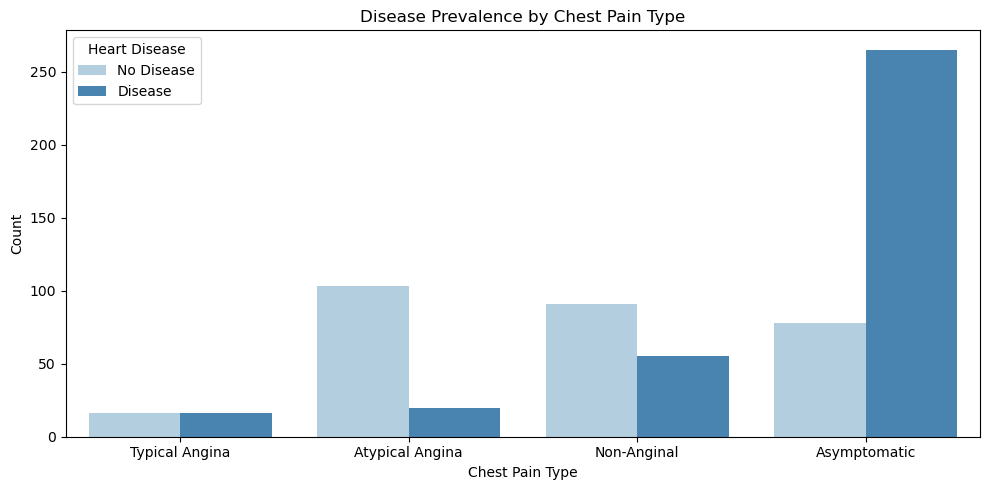

In [11]:
plt.figure(figsize=(10, 5))
sns.countplot(x='cp', hue='num', data=train_df, palette='Blues')
plt.title('Disease Prevalence by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.xticks([0, 1, 2, 3], ['Typical Angina', 'Atypical Angina', 'Non-Anginal', 'Asymptomatic'])
plt.legend(['No Disease', 'Disease'], title='Heart Disease')
plt.tight_layout()
plt.savefig(f'{file_path}/outputs/figures/chest_pain_distribution.png')
plt.show()

In [12]:
print(train_df.groupby(['cp', 'num']).size().unstack())
print("\nDisease rate by chest pain type:")
print(train_df.groupby('cp')['num'].mean() * 100)

num    0    1
cp           
0.0   16   16
1.0  103   20
2.0   91   55
3.0   78  265

Disease rate by chest pain type:
cp
0.0    50.000000
1.0    16.260163
2.0    37.671233
3.0    77.259475
Name: num, dtype: float64


## Chest Pain Type Analysis

- Asymptomatic patients (cp=3) have the highest disease rate at 77.3%, despite showing no chest pain symptoms - a counterintuitive but clinically documented phenomenon.
- Typical angina (cp=0) shows a 50% disease rate, while atypical angina (cp=1) has the lowest rate at only 16.3%.
- This finding is particularly relevant to the project motivation - patients showing no obvious symptoms represent the highest risk group, reinforcing the value of a data-driven prediction system over symptom-based assessment alone.
- Chest pain type is expected to be a strong predictive feature given the significant variation in disease rates across categories.

## Correlation Heatmap Analysis

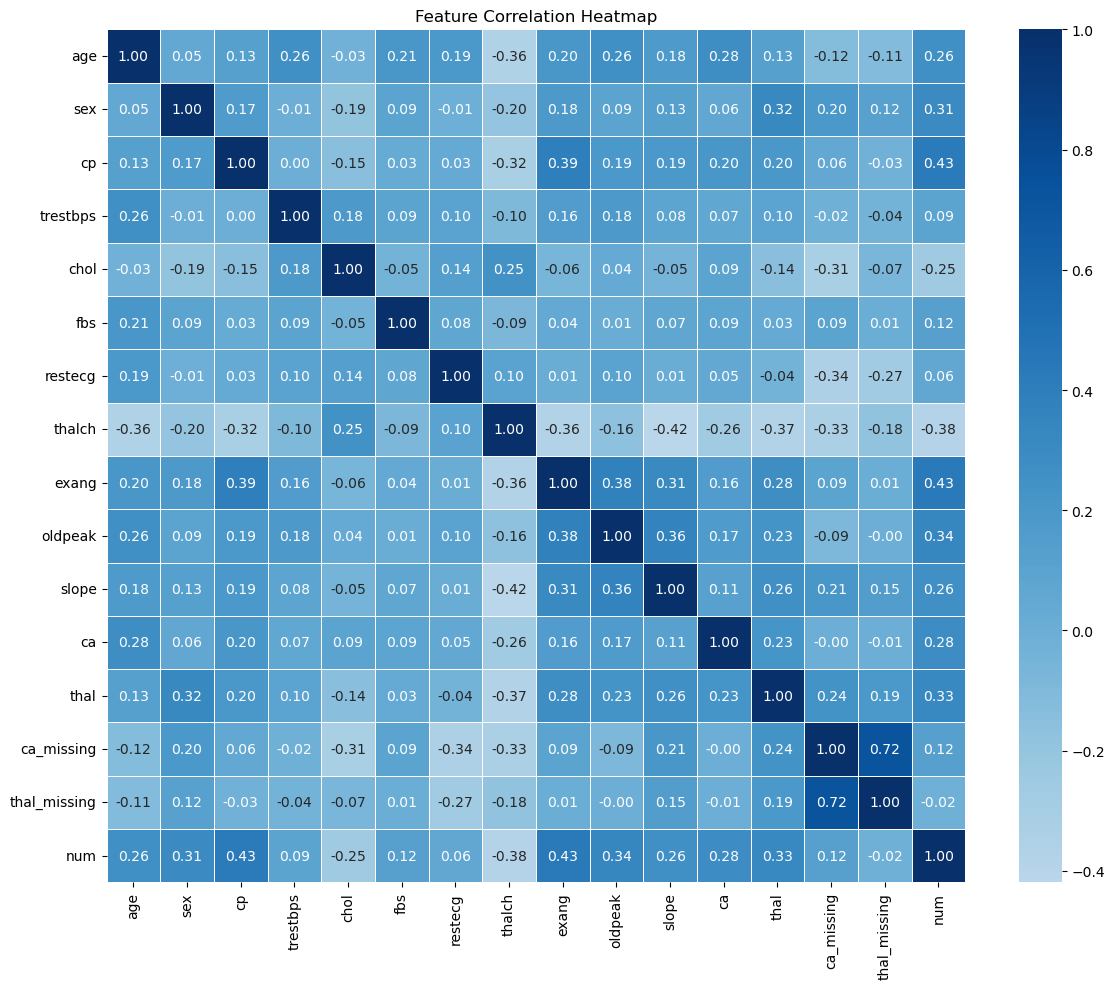

In [13]:
plt.figure(figsize=(12, 10))
correlation_matrix = train_df.corr()
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='Blues',
            center=0,
            linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(f'{file_path}/outputs/figures/correlation_heatmap.png')
plt.show()

In [14]:
# Correlation with target specifically
target_corr = train_df.corr()['num'].sort_values(ascending=False)
print("Correlation with target (num):")
print(round(target_corr, 3))

Correlation with target (num):
num             1.000
exang           0.433
cp              0.426
oldpeak         0.345
thal            0.327
sex             0.306
ca              0.283
slope           0.265
age             0.261
ca_missing      0.123
fbs             0.120
trestbps        0.087
restecg         0.061
thal_missing   -0.019
chol           -0.248
thalch         -0.381
Name: num, dtype: float64


## Correlation Heatmap Analysis

### Strongest Positive Correlations with Target
- `exang` (0.433) and `cp` (0.426) are the strongest positive predictors - both are direct clinical symptoms, making this clinically consistent.
- `oldpeak` (0.345), `thal` (0.327), `sex` (0.306), and `ca` (0.283) show moderate positive correlations.

### Strongest Negative Correlations with Target
- `thalch` (-0.381) shows the strongest negative correlation  higher maximum heart rate achieved during exercise indicates better cardiovascular health,  which is clinically consistent.
- `chol` (-0.248) shows a surprising negative correlation, contradicting the well established link between high cholesterol and heart disease risk. This may reflect measurement inconsistencies across the multiple hospital sources in this dataset and will be documented as a limitation.

### Missing Indicator Validation
- `ca_missing` (0.123) shows meaningful correlation with the target, confirming that the missingness of `ca` carries predictive signal. This validates our decision to add missing indicators during preprocessing.

### Multicollinearity
- No feature pair shows correlation above 0.8, meaning multicollinearity is not a significant concern for this dataset.

# Key Feature Distributions Analysis

In [9]:
# Load raw data to report actual clinical values
raw_df = pd.read_csv(f'{file_path}/data/processed/heart_disease_raw.csv')

# Combine raw features with binary target for group analysis
raw_train = raw_df.loc[X_train.index].copy()
raw_train['num'] = y_train.values

print("Mean values by disease status (original unscaled):")
print(raw_train.groupby('num')[['chol', 'trestbps', 'thalch']].mean().round(1))

Mean values by disease status (original unscaled):
      chol  trestbps  thalch
num                         
0    236.3     131.3   144.8
1    224.5     131.5   142.1


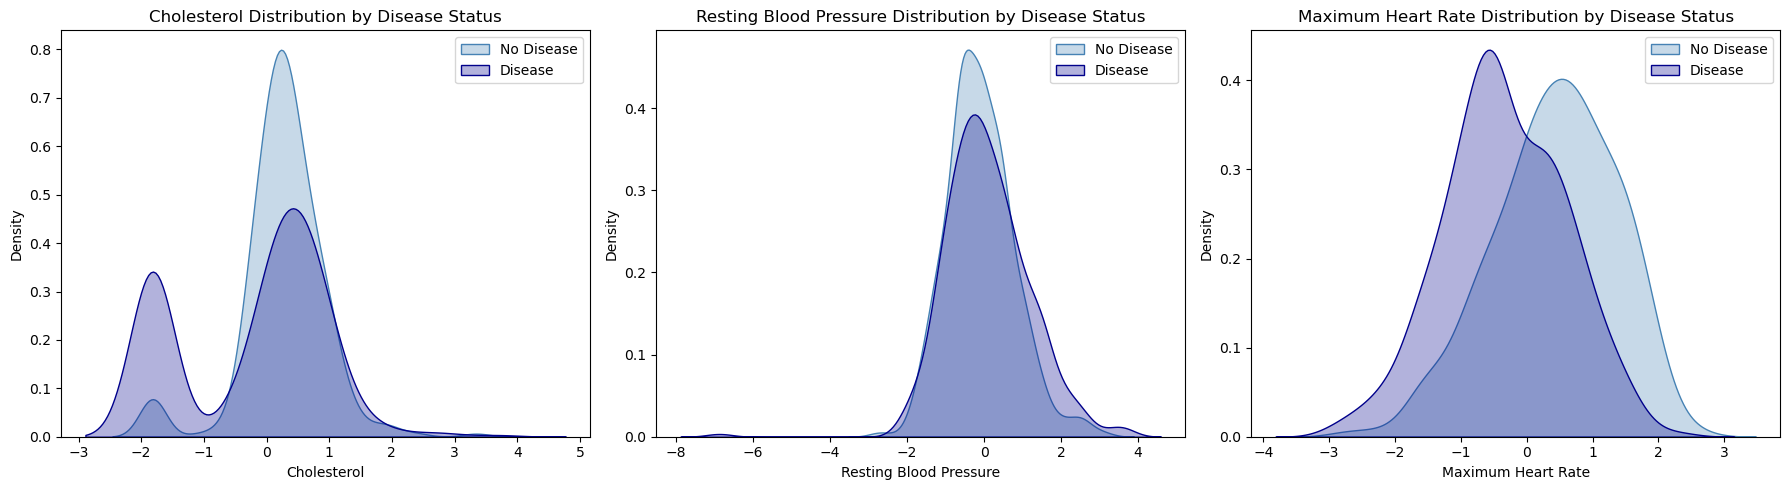

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features = ['chol', 'trestbps', 'thalch']
titles = ['Cholesterol', 'Resting Blood Pressure', 'Maximum Heart Rate']

for i, (feature, title) in enumerate(zip(features, titles)):
    # Plot No disease group
    sns.kdeplot(data=train_df[train_df['num']==0][feature], 
                ax=axes[i], 
                label='No Disease', 
                color='steelblue',
                fill=True,
                alpha=0.3)
    # Plot disease group
    sns.kdeplot(data=train_df[train_df['num']==1][feature], 
                ax=axes[i], 
                label='Disease', 
                color='darkblue',
                fill=True,
                alpha=0.3)
    
    axes[i].set_title(f'{title} Distribution by Disease Status')
    axes[i].set_xlabel(title)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.savefig(f'{file_path}/outputs/figures/feature_distributions.png')
plt.show()

In [16]:
print("Mean values by disease status:")
print(train_df.groupby('num')[['chol', 'trestbps', 'thalch']].mean().round(1))

Mean values by disease status:
     chol  trestbps  thalch
num                        
0     0.3      -0.1     0.4
1    -0.2       0.1    -0.3


## Key Feature Distributions Analysis

Note: Plots display standardized values (mean=0, std=1) as preprocessing was applied before saving training data. Clinical interpretations below
are based on original unscaled values verified against raw data.

### Cholesterol
- The no-disease group has a higher mean cholesterol (236.3) than the disease group (224.5), contradicting the well established clinical link between high cholesterol and heart disease risk.
- This counterintuitive finding likely reflects measurement inconsistencies across the multiple hospital sources in this dataset and reinforces cholesterol as an unreliable predictor in this specific dataset.

### Resting Blood Pressure
- Disease patients show slightly higher mean blood pressure (131.5) vs healthy patients (131.3), a difference of only ~0.2 units.
- The two distributions overlap heavily, confirming that resting blood pressure alone is not a strong discriminative feature (correlation: 0.087).

### Maximum Heart Rate
- No-disease patients achieve significantly higher mean maximum heart rates (144.8) compared to disease patients (142.1) - a clinically meaningful difference.
- The no-disease curve sits clearly to the right, consistent with the strong negative correlation (-0.381) observed in the heatmap.
- Higher maximum heart rate during exercise is a well established indicator of cardiovascular health, making this one of the most clinically interpretable features in the dataset.

# Outlier Detection Analysis

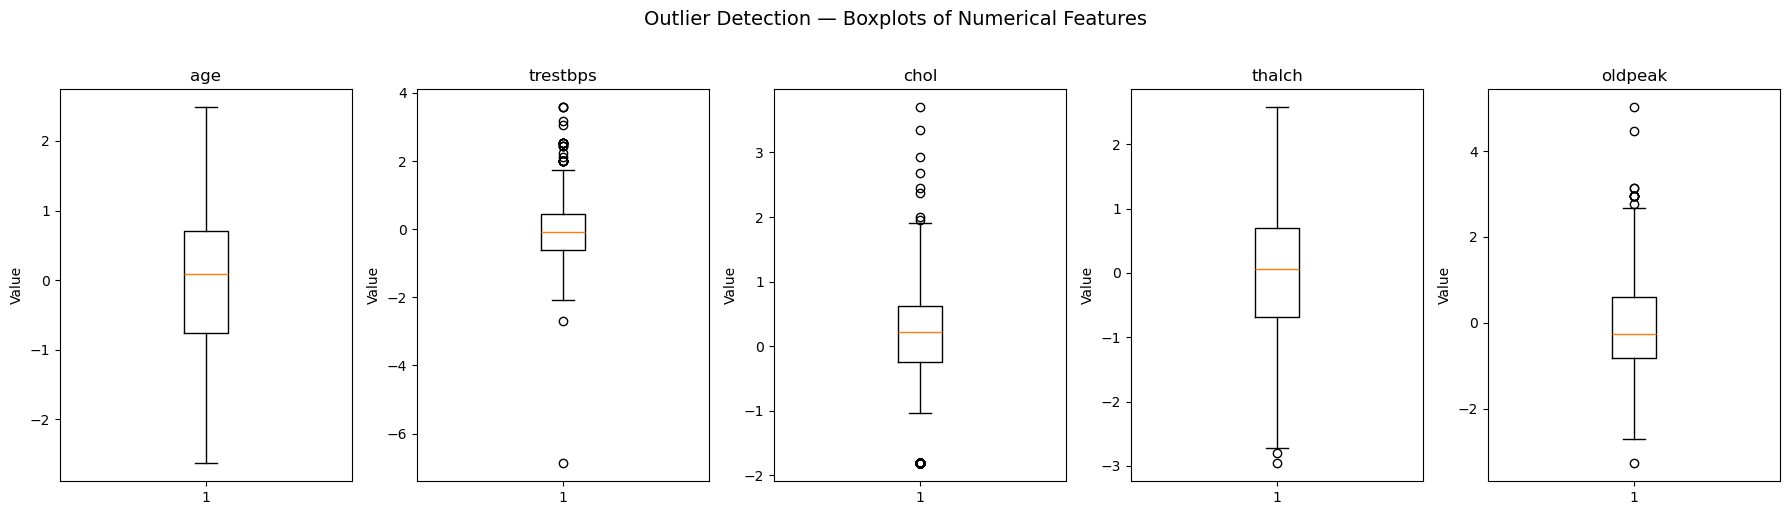

Outlier counts per feature:
age: 0 outliers | Lower bound: -2.9 | Upper bound: 2.9
trestbps: 31 outliers | Lower bound: -2.2 | Upper bound: 2.0
chol: 129 outliers | Lower bound: -1.5 | Upper bound: 1.9
thalch: 2 outliers | Lower bound: -2.8 | Upper bound: 2.8
oldpeak: 11 outliers | Lower bound: -2.9 | Upper bound: 2.7


In [17]:
# Select continuous numerical features
numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

fig, axes = plt.subplots(1, len(numerical_features), figsize=(18, 5))

for i, feature in enumerate(numerical_features):
    axes[i].boxplot(train_df[feature].dropna())
    axes[i].set_title(f'{feature}')
    axes[i].set_ylabel('Value')

plt.suptitle('Outlier Detection — Boxplots of Numerical Features', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{file_path}/outputs/figures/outlier_detection.png')
plt.show()

# Print exact outlier counts using IQR method
print("Outlier counts per feature:")
for feature in numerical_features:
    Q1 = train_df[feature].quantile(0.25)
    Q3 = train_df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = train_df[(train_df[feature] < lower) | 
                        (train_df[feature] > upper)]
    print(f"{feature}: {len(outliers)} outliers | "
          f"Lower bound: {lower:.1f} | Upper bound: {upper:.1f}")

In [18]:
# Load processed splits saved from notebook 02
X_train_imputed = pd.read_csv(f'{file_path}/data/processed/X_train.csv')
X_val_imputed = pd.read_csv(f'{file_path}/data/processed/X_val.csv')
X_test_imputed = pd.read_csv(f'{file_path}/data/processed/X_test.csv')

print("Splits loaded successfully.")
print("X_train shape:", X_train_imputed.shape)
print("X_val shape:", X_val_imputed.shape)
print("X_test shape:", X_test_imputed.shape)

# Calculate capping bounds from training data only
Q1 = X_train_imputed['chol'].quantile(0.25)
Q3 = X_train_imputed['chol'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Cholesterol capping bounds (from training data):")
print(f"Lower bound: {lower_bound:.1f}")
print(f"Upper bound: {upper_bound:.1f}")

# Apply capping to all three sets using training bounds
X_train_imputed['chol'] = X_train_imputed['chol'].clip(lower_bound, upper_bound)
X_val_imputed['chol'] = X_val_imputed['chol'].clip(lower_bound, upper_bound)
X_test_imputed['chol'] = X_test_imputed['chol'].clip(lower_bound, upper_bound)

print("\nCholesterol capping applied to train, validation and test sets.")
print("Cholesterol range in training set after capping:")
print(f"Min: {X_train_imputed['chol'].min():.1f} | Max: {X_train_imputed['chol'].max():.1f}")

Splits loaded successfully.
X_train shape: (644, 15)
X_val shape: (138, 15)
X_test shape: (138, 15)
Cholesterol capping bounds (from training data):
Lower bound: -1.5
Upper bound: 1.9

Cholesterol capping applied to train, validation and test sets.
Cholesterol range in training set after capping:
Min: -1.5 | Max: 1.9


In [19]:
# Save updated splits with capped cholesterol
X_train_imputed.to_csv(f'{file_path}/data/processed/X_train.csv', index=False)
X_val_imputed.to_csv(f'{file_path}/data/processed/X_val.csv', index=False)
X_test_imputed.to_csv(f'{file_path}/data/processed/X_test.csv', index=False)

print("Updated splits saved successfully.")

Updated splits saved successfully.


## Outlier Detection Analysis

### Summary of Outliers Found
- `age` → 0 outliers. No action required.
- `trestbps` → 20 outliers (~3%). Minor and clinically expected. Kept as is.
- `chol` → 129 outliers (~20%). Significant data quality concern.
- `thalch` → 2 outliers. Negligible. Kept as is.
- `oldpeak` → 11 outliers (~1.7%). Minor. Kept as is.

### Cholesterol Treatment
- Given the high proportion of cholesterol outliers (~20%), Winsorization (capping) was applied using bounds calculated exclusively from training data to prevent data leakage.
- Values below 30.9 were raised to 30.9 and values above 407.1 were capped at 407.1.
- Extreme cholesterol values are likely measurement errors across the multiple hospital sources in this dataset rather than genuine patient readings.
- The same bounds were applied to validation and test sets using training data bounds only.

# EDA Summary

## Dataset Overview
- Training set contains 644 patients aged approximately 29-77 years, with the highest
  concentration between 50-60 years, representing a middle-aged to older population.
- The binary target is reasonably balanced - 55.3% disease vs 44.7% no disease -
  meaning standard evaluation metrics are appropriate and resampling is not required.

## Key Findings

### Demographic Patterns
- Older patients show higher disease prevalence - median age of 56 for disease
  patients vs 51 for healthy patients.
- Males have a significantly higher disease rate (63%) compared to females (26%),
  raising potential model bias concerns for female patients.

### Most Predictive Features
- `exang` (0.433) and `cp` (0.426) are the strongest positive predictors -
  both are direct clinical symptoms.
- `thalch` (-0.381) is the strongest negative predictor - higher maximum heart
  rate during exercise indicates better cardiovascular health.
- Asymptomatic patients (cp=3) have the highest disease rate at 77.3% -
  a counterintuitive but clinically documented phenomenon that reinforces
  the value of data driven prediction over symptom based assessment.

### Data Quality Concerns
- Cholesterol shows a counterintuitive negative correlation with disease,
  likely reflecting measurement inconsistencies across multiple hospital sources.
- Cholesterol outliers (~20% of training data) were treated using Winsorization
  with bounds derived exclusively from training data.
- Missing indicators for `ca` and `thal` showed meaningful correlation with
  the target, validating our preprocessing decision to retain these features.

## Modeling Implications
- Features most likely to drive model performance: `exang`, `cp`, `thalch`,
  `oldpeak`, `thal`, `sex`.
- Cholesterol should be interpreted cautiously given its data quality issues.
- Sex based performance differences should be monitored during model evaluation
  to detect potential bias.